**DATASET INFORMATION**

The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed.


The classification goal is to predict if the client will subscribe (yes/no) a term deposit (variable y).

LINK: [https://archive.ics.uci.edu/dataset/222/bank+marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
df = pd.read_csv('/content/bank-full.csv', sep=';')

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
print(df.info())
print("\nMissing Values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Missing Values:

age          0
job          0
marital      0
education    0
default      0
b

In [4]:
X = df.drop('y', axis=1)
y = df['y']

In [5]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
print("Target Classes:", y.unique())

Features Shape: (45211, 16)
Target Shape: (45211,)
Target Classes: ['no' 'yes']


In [6]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical Columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


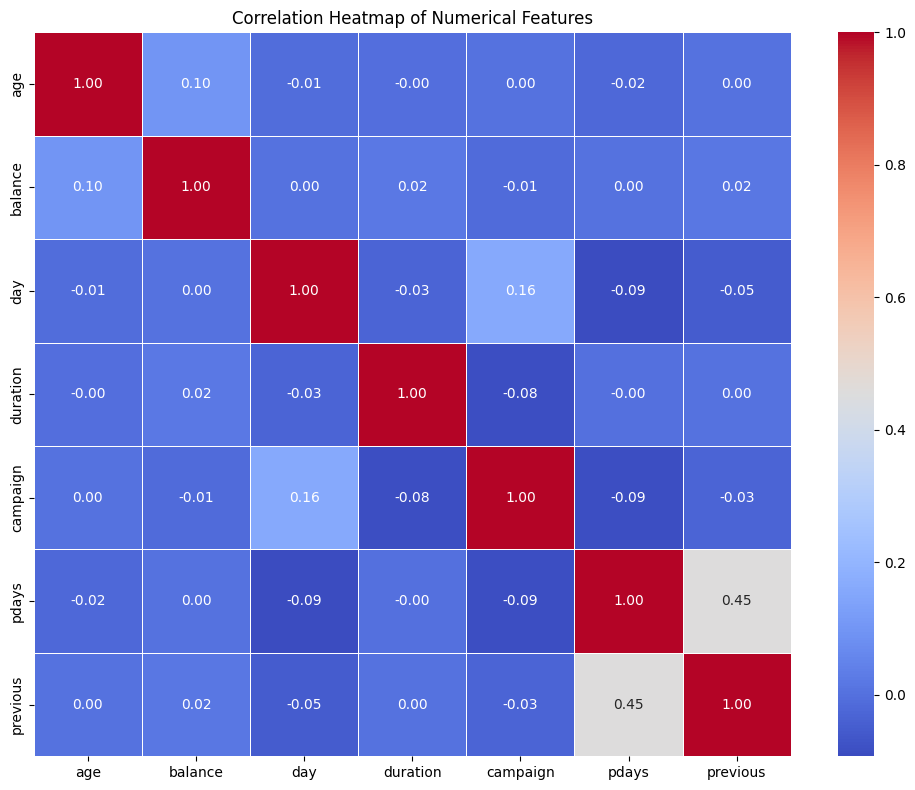

In [7]:
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

/tmp/ipykernel_9633/919573550.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=['crimson', 'royalblue'])


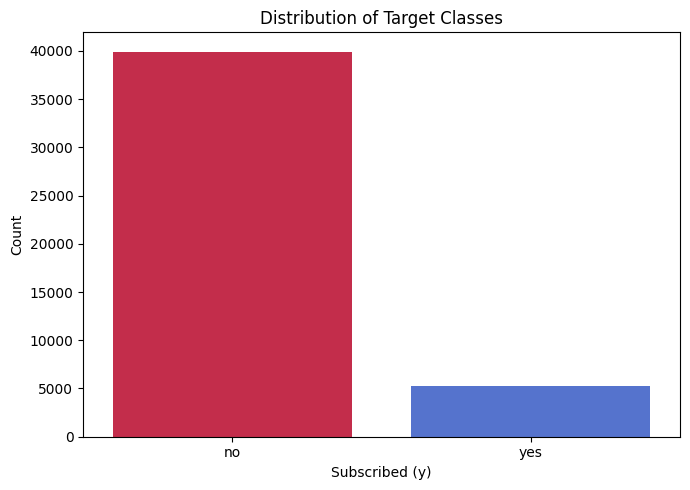

In [8]:
plt.figure(figsize=(7, 5))
sns.countplot(x=y, palette=['crimson', 'royalblue'])
plt.xlabel('Subscribed (y)')
plt.ylabel('Count')
plt.title('Distribution of Target Classes')
plt.tight_layout()
plt.show()

/tmp/ipykernel_9633/2739420749.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=df[col], ax=ax, palette=['crimson', 'royalblue'])
/tmp/ipykernel_9633/2739420749.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=df[col], ax=ax, palette=['crimson', 'royalblue'])
/tmp/ipykernel_9633/2739420749.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=df[col], ax=ax, palette=['crimson', 'royalblue'])
/tmp/ipykernel_9633/2739420749.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

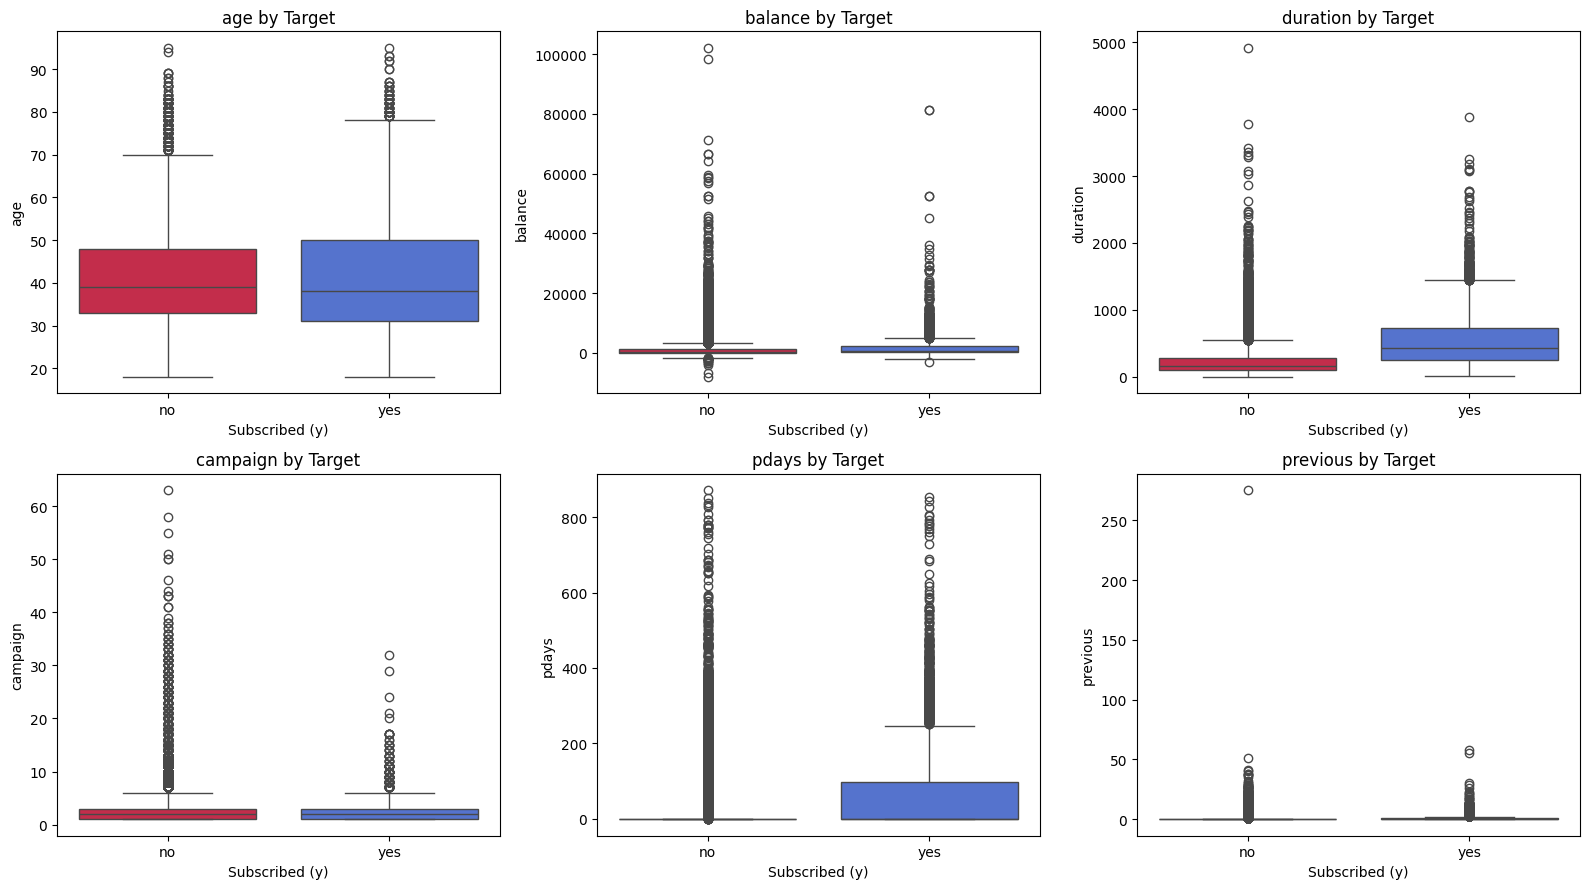

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
key_numerical = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

for ax, col in zip(axes, key_numerical):
    sns.boxplot(x=y, y=df[col], ax=ax, palette=['crimson', 'royalblue'])
    ax.set_title(f'{col} by Target')
    ax.set_xlabel('Subscribed (y)')

plt.tight_layout()
plt.show()

In [10]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("Encoded Feature Shape:", X_encoded.shape)
X_encoded.head()

Encoded Feature Shape: (45211, 42)


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [11]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Encoded Target Classes:", dict(zip(le.classes_, le.transform(le.classes_))))

Encoded Target Classes: {'no': np.int64(0), 'yes': np.int64(1)}


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Scaled Data Shape:", X_scaled.shape)
print("Mean of Scaled Data (approx 0):", np.round(np.mean(X_scaled), 4))
print("Std of Scaled Data (approx 1):", np.round(np.std(X_scaled), 4))

Scaled Data Shape: (45211, 42)
Mean of Scaled Data (approx 0): -0.0
Std of Scaled Data (approx 1): 1.0


In [13]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
print("Explained Variance Ratio of First 10 Components:")
print(np.round(explained_variance_ratio[:10], 4))

Explained Variance Ratio of First 10 Components:
[0.0718 0.0636 0.0559 0.046  0.0402 0.0334 0.0329 0.0309 0.0298 0.0288]


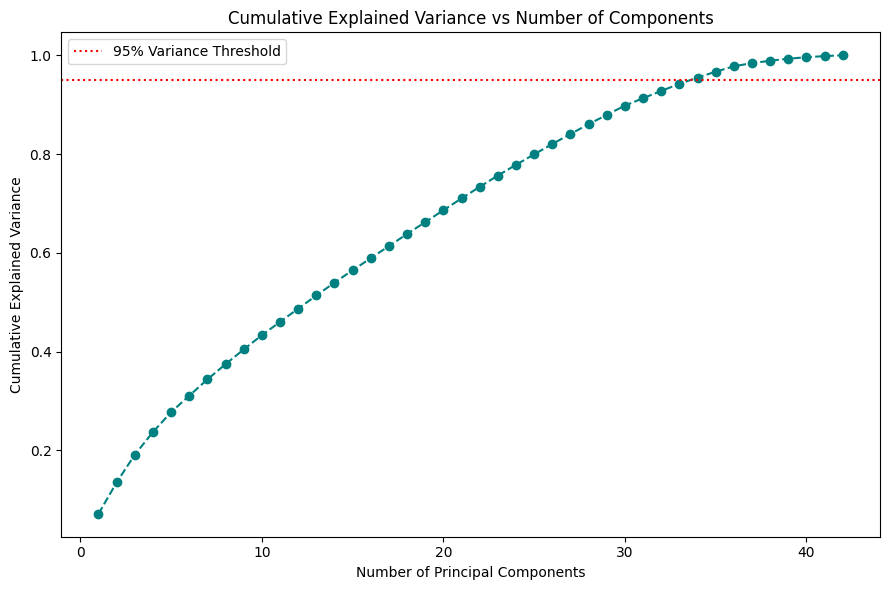

In [14]:
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(9, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='teal')
plt.axhline(y=0.95, color='red', linestyle=':', label='95% Variance Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Components')
plt.legend()
plt.tight_layout()
plt.show()

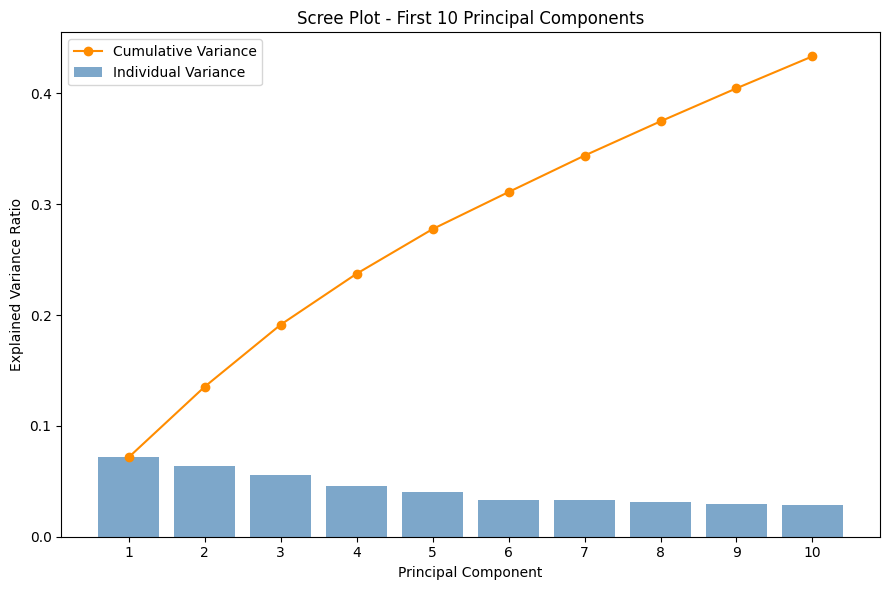

In [15]:
plt.figure(figsize=(9, 6))
components = range(1, 11)
plt.bar(components, explained_variance_ratio[:10], color='steelblue', alpha=0.7, label='Individual Variance')
plt.plot(components, np.cumsum(explained_variance_ratio[:10]), color='darkorange', marker='o', label='Cumulative Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - First 10 Principal Components')
plt.xticks(components)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

print("PCA Reduced Data Shape:", X_pca.shape)
print("Explained Variance by 2 Components:", np.round(pca_2d.explained_variance_ratio_, 4))
print("Total Variance Captured:", np.round(np.sum(pca_2d.explained_variance_ratio_), 4))

PCA Reduced Data Shape: (45211, 2)
Explained Variance by 2 Components: [0.0718 0.0636]
Total Variance Captured: 0.1354


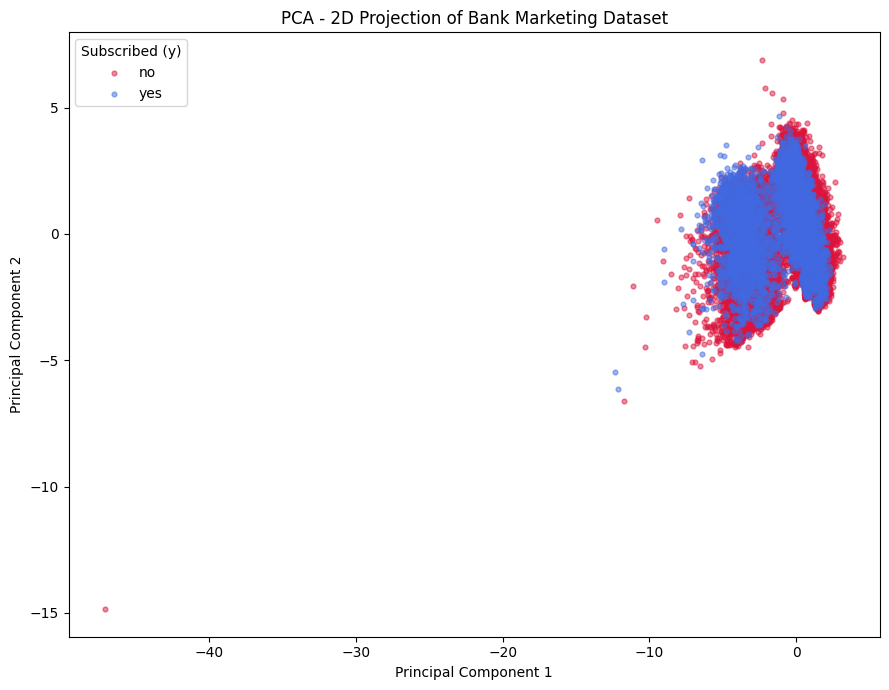

In [17]:
plt.figure(figsize=(9, 7))
colors = {'no': 'crimson', 'yes': 'royalblue'}
for label in y.unique():
    mask = y == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label, alpha=0.5, s=12, color=colors[label])

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - 2D Projection of Bank Marketing Dataset')
plt.legend(title='Subscribed (y)')
plt.tight_layout()
plt.show()

In [18]:
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], size=5000, replace=False)

X_sample = X_scaled[sample_indices]
y_sample = y.iloc[sample_indices].reset_index(drop=True)

print("Sampled Data Shape:", X_sample.shape)

Sampled Data Shape: (5000, 42)


In [19]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)

print("t-SNE Reduced Data Shape:", X_tsne.shape)

t-SNE Reduced Data Shape: (5000, 2)


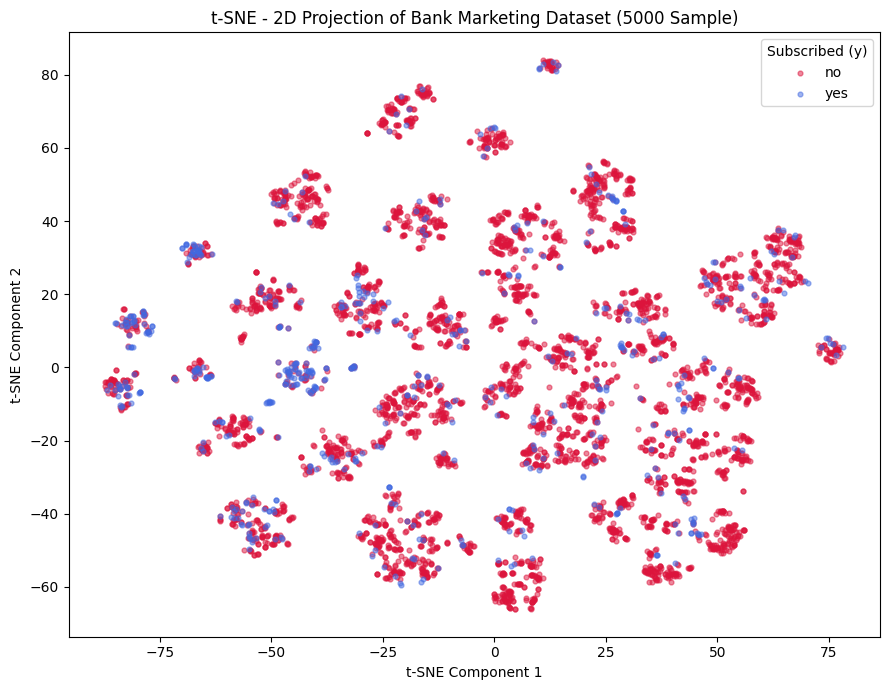

In [20]:
plt.figure(figsize=(9, 7))
for label in y_sample.unique():
    mask = y_sample == label
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=label, alpha=0.5, s=12, color=colors[label])

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE - 2D Projection of Bank Marketing Dataset (5000 Sample)')
plt.legend(title='Subscribed (y)')
plt.tight_layout()
plt.show()

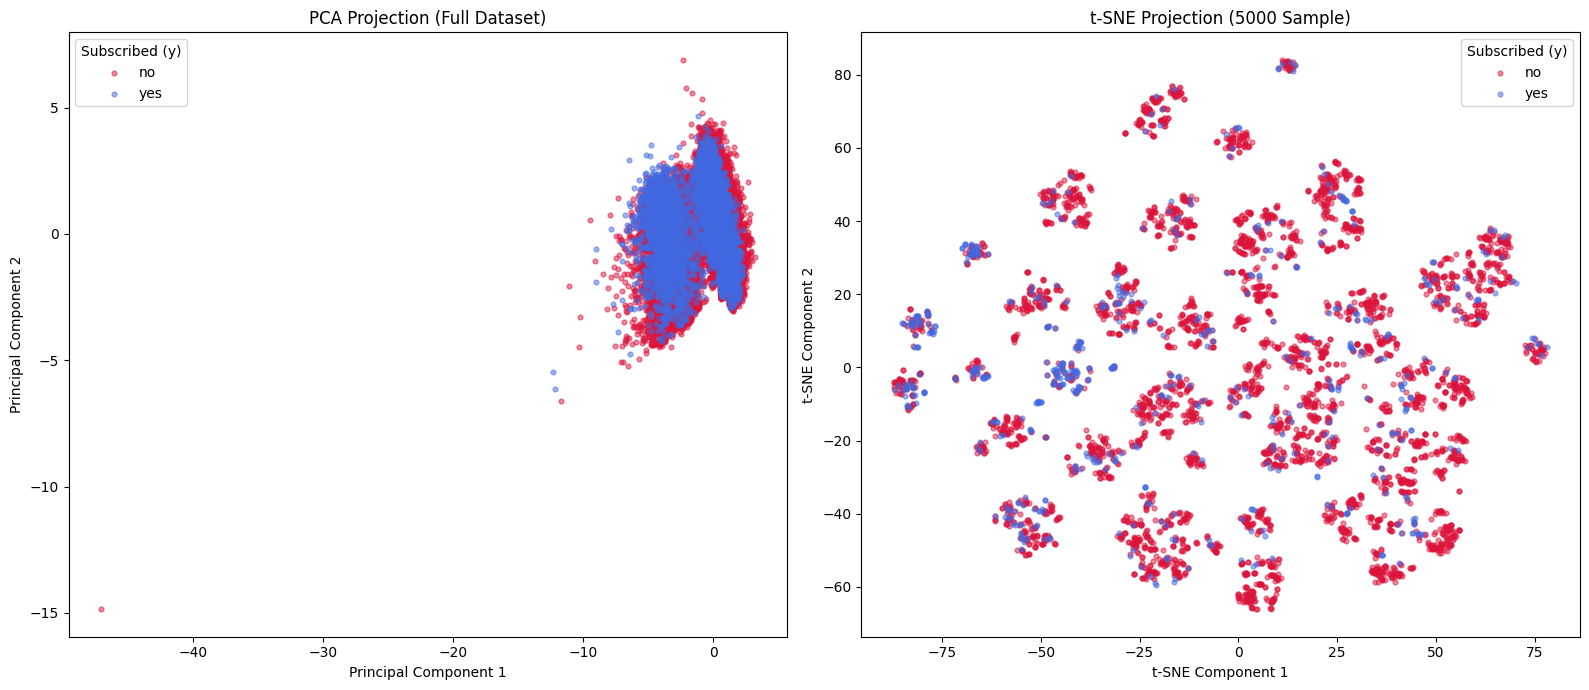

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for label in y.unique():
    mask = y == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=label, alpha=0.5, s=12, color=colors[label])
axes[0].set_title('PCA Projection (Full Dataset)')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend(title='Subscribed (y)')

for label in y_sample.unique():
    mask = y_sample == label
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=label, alpha=0.5, s=12, color=colors[label])
axes[1].set_title('t-SNE Projection (5000 Sample)')
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].legend(title='Subscribed (y)')

plt.tight_layout()
plt.show()

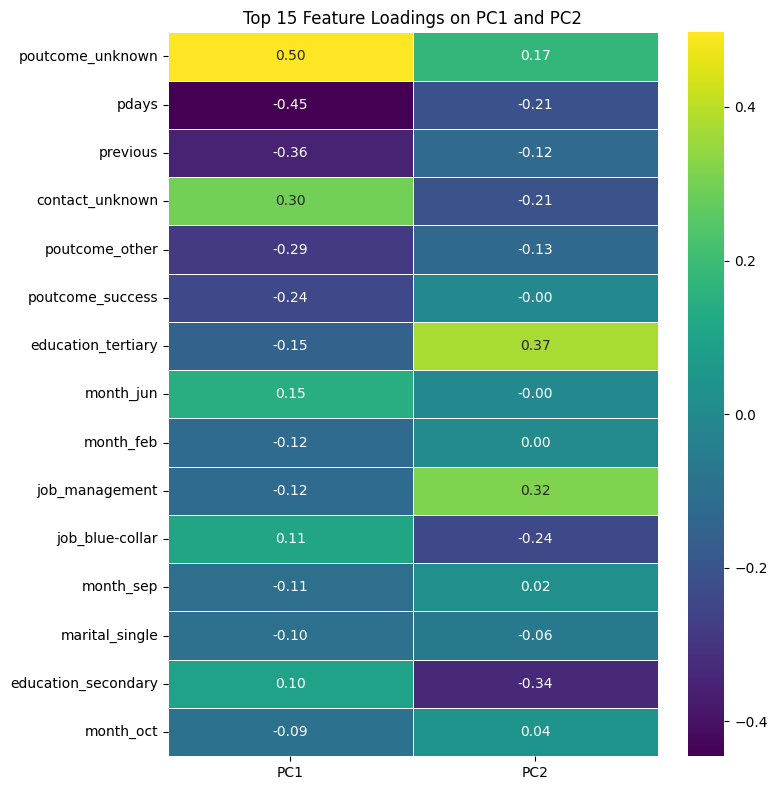

In [22]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=X_encoded.columns
)
top_loadings = loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index[:15])

plt.figure(figsize=(8, 8))
sns.heatmap(top_loadings, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title('Top 15 Feature Loadings on PC1 and PC2')
plt.tight_layout()
plt.show()

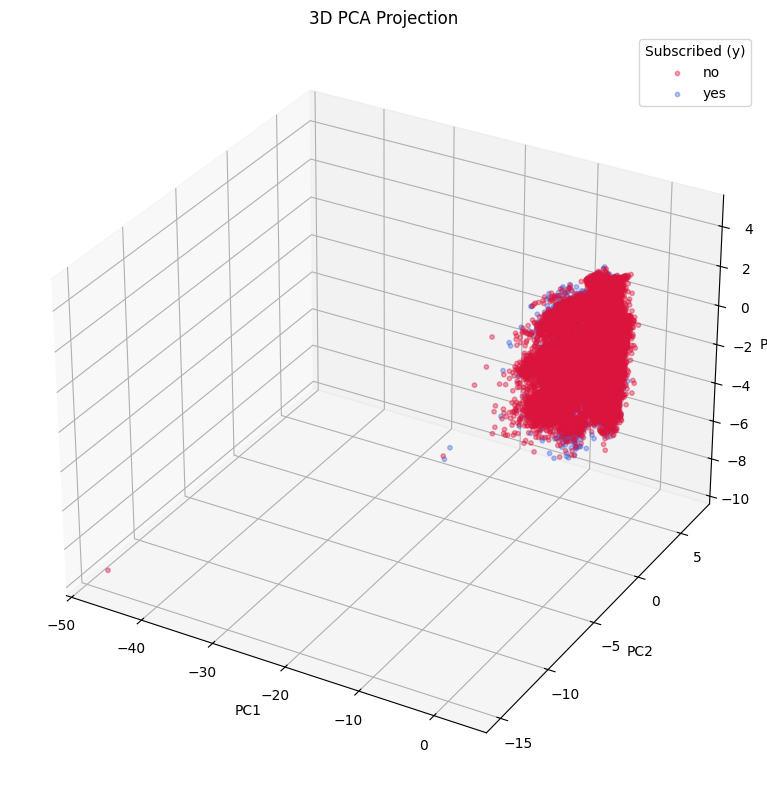

In [23]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for label in y.unique():
    mask = y == label
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               label=label, alpha=0.4, s=10, color=colors[label])

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Projection')
ax.legend(title='Subscribed (y)')
plt.tight_layout()
plt.show()

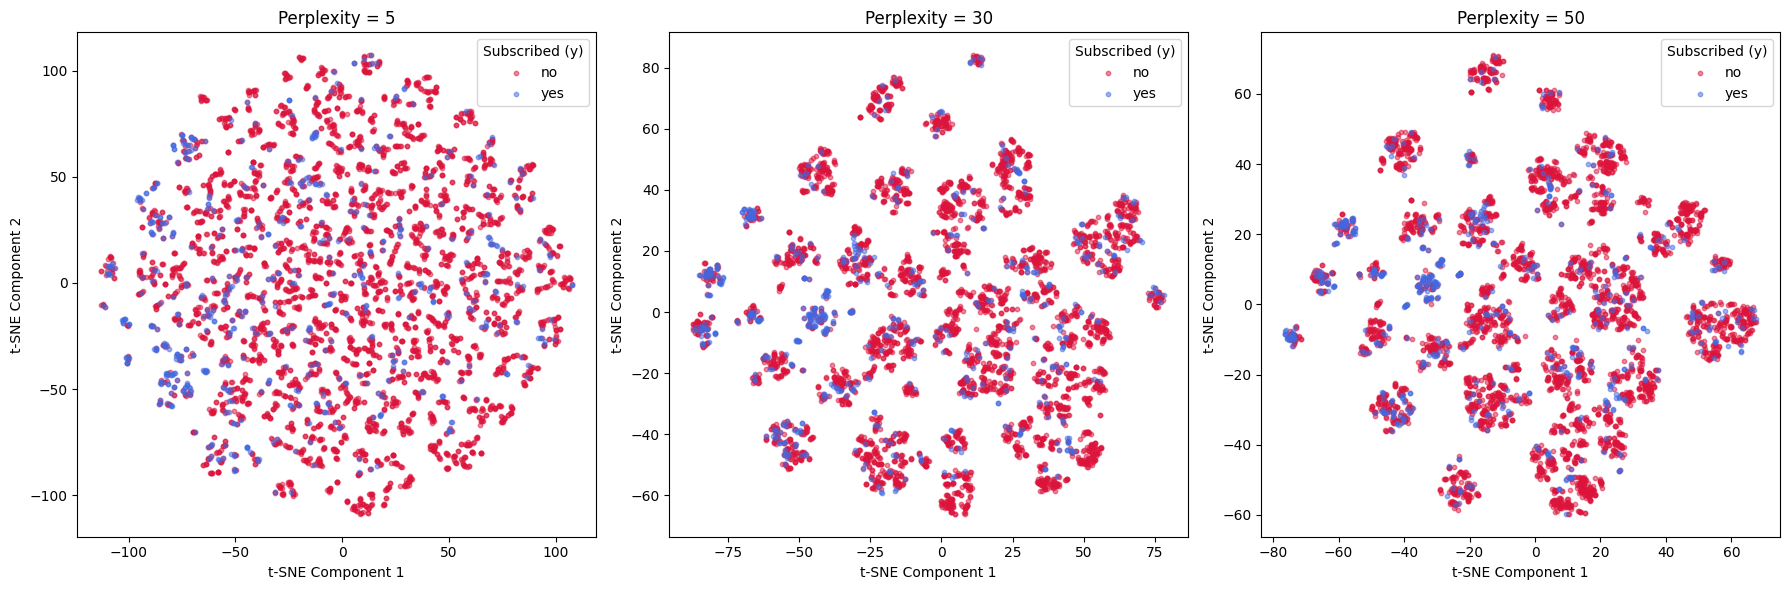

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
perplexities = [5, 30, 50]

for ax, perp in zip(axes, perplexities):
    tsne_temp = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca', learning_rate='auto')
    X_tsne_temp = tsne_temp.fit_transform(X_sample)
    for label in y_sample.unique():
        mask = y_sample == label
        ax.scatter(X_tsne_temp[mask, 0], X_tsne_temp[mask, 1], label=label, alpha=0.5, s=10, color=colors[label])
    ax.set_title(f'Perplexity = {perp}')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.legend(title='Subscribed (y)')

plt.tight_layout()
plt.show()

In [25]:
print("Original Feature Data Shape:", X.shape)
print("One-Hot Encoded Data Shape:", X_encoded.shape)
print("Scaled Data Shape:", X_scaled.shape)
print("PCA Output Shape (2 Components):", X_pca.shape)
print("t-SNE Sample Input Shape:", X_sample.shape)
print("t-SNE Output Shape (2 Components):", X_tsne.shape)

Original Feature Data Shape: (45211, 16)
One-Hot Encoded Data Shape: (45211, 42)
Scaled Data Shape: (45211, 42)
PCA Output Shape (2 Components): (45211, 2)
t-SNE Sample Input Shape: (5000, 42)
t-SNE Output Shape (2 Components): (5000, 2)
